# Exploratory Data Analysis

Household electricity consumption + weather, Sceaux, France (2006-2010).

In [1]:
import sys
sys.path.insert(0, '..')
import matplotlib.pyplot as plt
import pandas as pd

from src.config import load_config, resolve_path

config = load_config()
path = resolve_path(config['data']['processed_dir']) / 'household_energy_hourly.csv'
df = pd.read_csv(path, parse_dates=['timestamp'], index_col='timestamp')
df.shape

(34168, 11)

In [2]:
df.describe()

,global_active_power_kw,global_reactive_power_kw,voltage_v,global_intensity_a,sub_metering_1_wh,sub_metering_2_wh,sub_metering_3_wh,temperature_2m,shortwave_radiation,wind_speed_10m,cloud_cover
count,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000
mean,1.091728,0.123727,240.839393,4.628238,1.121631,1.298566,6.458882,11.099028,134.268907,12.901958,66.105303
std,0.897619,0.066851,3.001093,3.757797,3.538046,4.192874,7.351219,6.957403,204.499847,6.443147,36.865808
min,0.124000,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000,-10.500000,0.000000,0.000000,0.000000
25%,0.341925,0.078000,239.180667,1.513333,0.000000,0.000000,0.650000,6.100000,0.000000,8.100000,34.000000
50%,0.802850,0.106917,240.977833,3.423333,0.000000,0.333333,1.650000,11.200000,7.000000,11.700000,83.000000
75%,1.579342,0.149433,242.695000,6.606667,0.000000,0.650000,14.216667,16.200000,214.000000,16.600000,100.000000
max,6.560533,0.774333,251.902000,28.383333,48.366667,46.433333,21.550000,34.700000,908.000000,51.700000,100.000000


## Missing values

The merged dataset should have zero missing values (verified by the data pipeline).

In [3]:
df.isna().sum()

global_active_power_kw      0
global_reactive_power_kw    0
voltage_v                   0
global_intensity_a          0
sub_metering_1_wh           0
sub_metering_2_wh           0
sub_metering_3_wh           0
temperature_2m              0
shortwave_radiation         0
wind_speed_10m              0
cloud_cover                 0
dtype: int64

## Consumption over a sample month

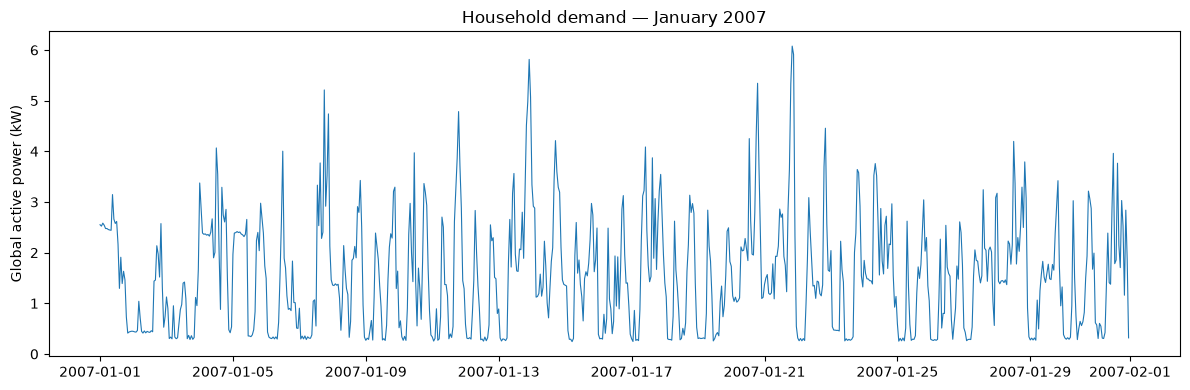

In [4]:
sample = df.loc['2007-01-01':'2007-01-31', 'global_active_power_kw']
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sample.index, sample.values, linewidth=0.8)
ax.set_title('Household demand — January 2007')
ax.set_ylabel('Global active power (kW)')
fig.tight_layout()

## Daily and weekly seasonality

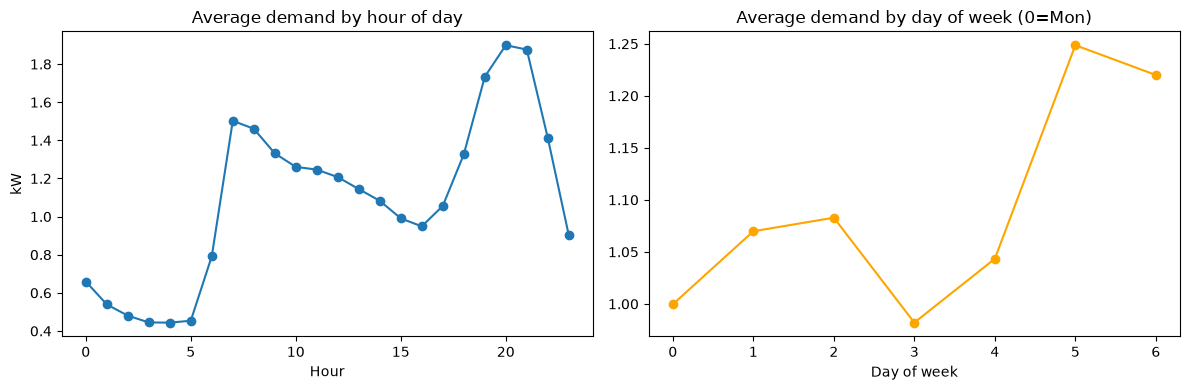

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.groupby(df.index.hour)['global_active_power_kw'].mean().plot(ax=axes[0], marker='o')
axes[0].set_title('Average demand by hour of day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('kW')

df.groupby(df.index.dayofweek)['global_active_power_kw'].mean().plot(ax=axes[1], marker='o', color='orange')
axes[1].set_title('Average demand by day of week (0=Mon)')
axes[1].set_xlabel('Day of week')
fig.tight_layout()

## Demand vs. weather

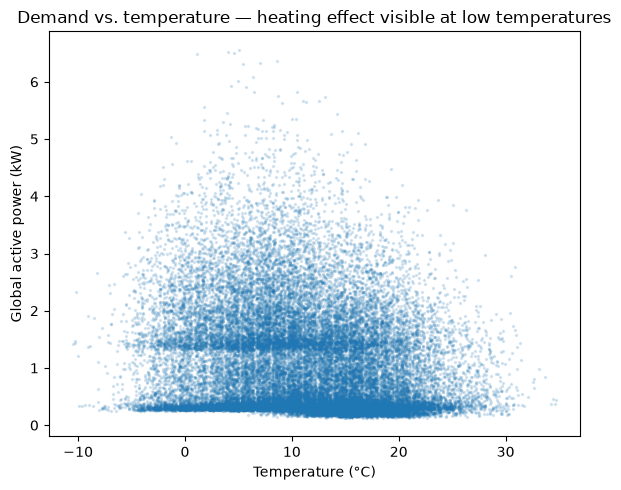

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df['temperature_2m'], df['global_active_power_kw'], s=2, alpha=0.15)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Global active power (kW)')
ax.set_title('Demand vs. temperature — heating effect visible at low temperatures')
fig.tight_layout()

In [7]:
df.corr(numeric_only=True)['global_active_power_kw'].sort_values(ascending=False)

global_active_power_kw      1.000000
global_intensity_a          0.999423
sub_metering_3_wh           0.695540
sub_metering_1_wh           0.496331
sub_metering_2_wh           0.440171
global_reactive_power_kw    0.312322
wind_speed_10m              0.058820
cloud_cover                 0.058386
shortwave_radiation        -0.068365
temperature_2m             -0.189476
voltage_v                  -0.379450
Name: global_active_power_kw, dtype: float64